In [52]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [54]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [55]:
df.describe()

,Class label,Alcohol,Malic acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


<Axes: xlabel='Alcohol', ylabel='Density'>

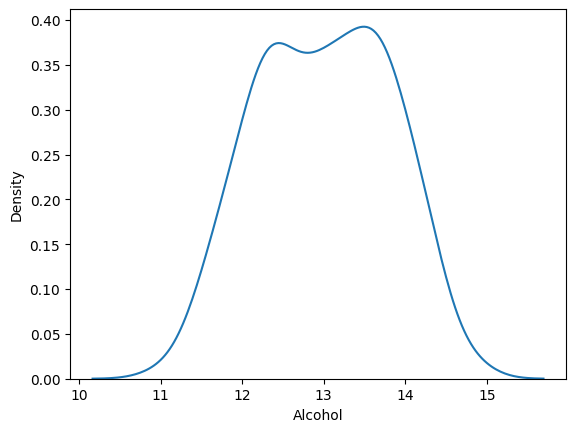

In [56]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

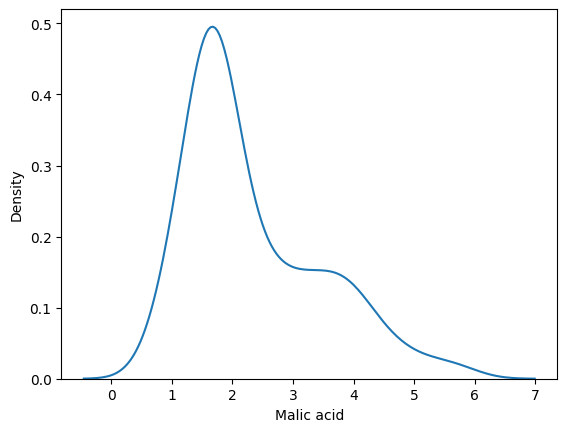

In [57]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

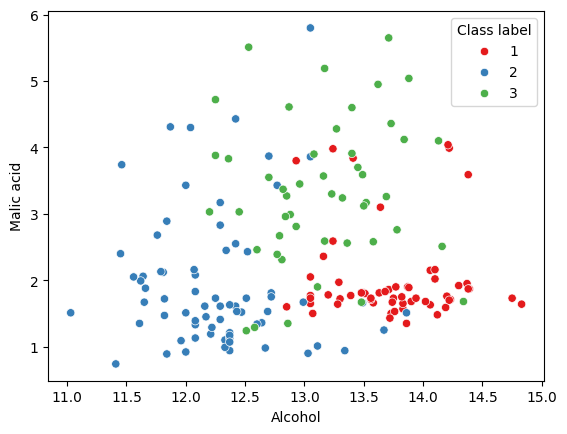

In [58]:
sns.scatterplot(x = df['Alcohol'], y = df['Malic acid'], hue = df['Class label'], palette = 'Set1')

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit on train set only
scaler.fit(X_train)

# Transform train and test sets and keep column names
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [61]:
# Ensure scaled outputs are DataFrames even if this cell is run independently
if not isinstance(X_train_scaled, pd.DataFrame):
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
if not isinstance(X_test_scaled, pd.DataFrame):
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Alcohol,Malic acid
22,0.720430,0.203782
108,0.319892,0.084034
175,0.602151,0.712185
145,0.572581,0.563025
71,0.760753,0.130252


In [62]:
np.round(X_train.describe())

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.0
std,1.0,1.0
min,11.0,1.0
25%,12.0,2.0
50%,13.0,2.0
75%,14.0,3.0
max,15.0,6.0


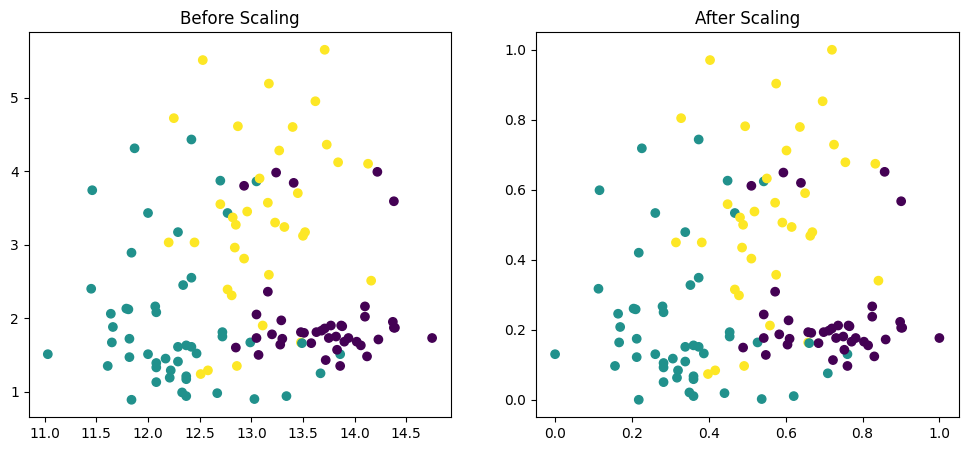

In [63]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

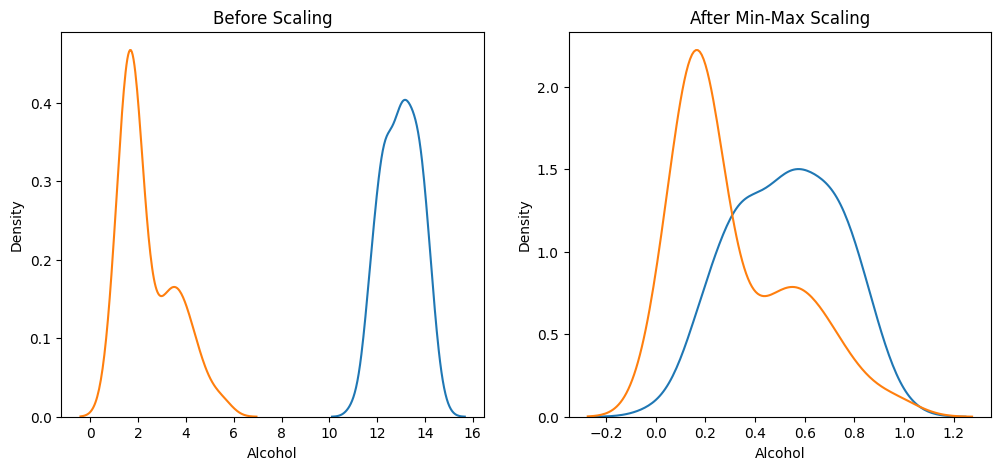

In [64]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Min-Max Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

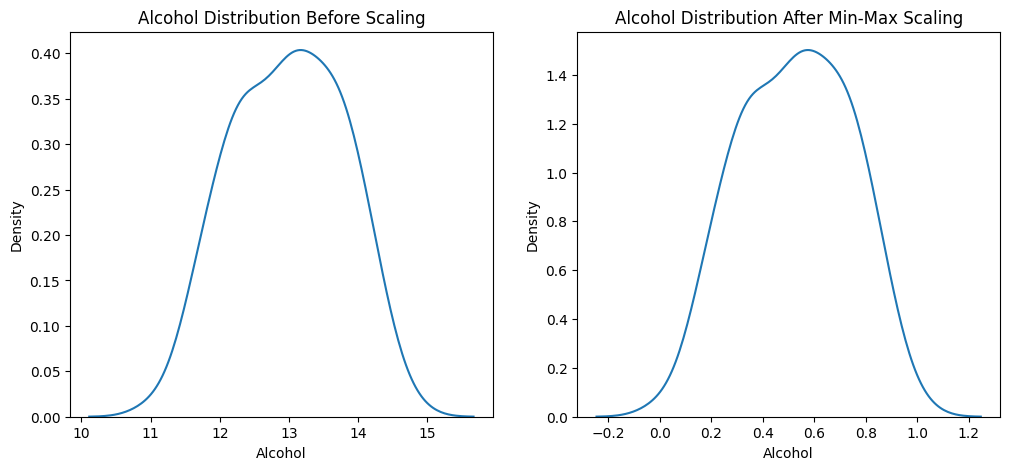

In [65]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Min-Max Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

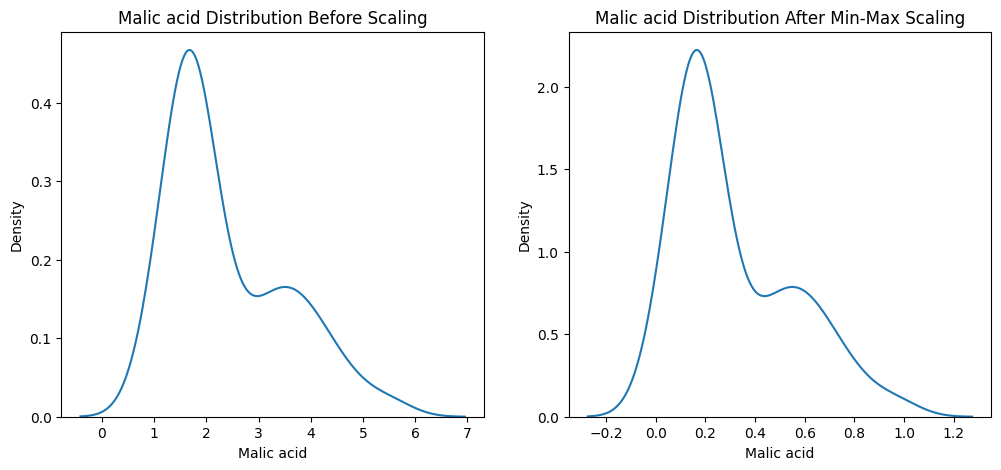

In [66]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Min-Max Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

     Alcohol_before  Alcohol_after  Malic acid_before  Malic acid_after
min           11.03            0.0               0.89               0.0
max           14.75            1.0               5.65               1.0


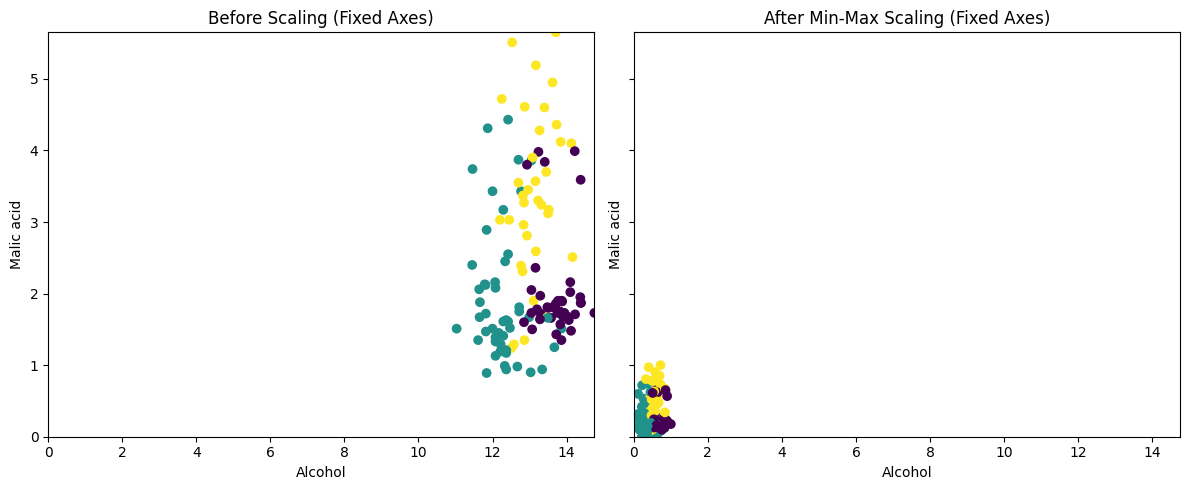

In [67]:
# Numeric check: min/max before and after scaling for both features
summary = pd.DataFrame({
    'Alcohol_before': [X_train['Alcohol'].min(), X_train['Alcohol'].max()],
    'Alcohol_after': [X_train_scaled['Alcohol'].min(), X_train_scaled['Alcohol'].max()],
    'Malic acid_before': [X_train['Malic acid'].min(), X_train['Malic acid'].max()],
    'Malic acid_after': [X_train_scaled['Malic acid'].min(), X_train_scaled['Malic acid'].max()]
}, index=['min', 'max'])
print(summary)

# Visual check: use identical axis limits on both subplots
alcohol_min = min(X_train['Alcohol'].min(), X_train_scaled['Alcohol'].min())
alcohol_max = max(X_train['Alcohol'].max(), X_train_scaled['Alcohol'].max())
malic_min = min(X_train['Malic acid'].min(), X_train_scaled['Malic acid'].min())
malic_max = max(X_train['Malic acid'].max(), X_train_scaled['Malic acid'].max())

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5), sharex=True, sharey=True)

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train, cmap='viridis')
ax1.set_title('Before Scaling (Fixed Axes)')
ax1.set_xlim(alcohol_min, alcohol_max)
ax1.set_ylim(malic_min, malic_max)
ax1.set_xlabel('Alcohol')
ax1.set_ylabel('Malic acid')

ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train, cmap='viridis')
ax2.set_title('After Min-Max Scaling (Fixed Axes)')
ax2.set_xlim(alcohol_min, alcohol_max)
ax2.set_ylim(malic_min, malic_max)
ax2.set_xlabel('Alcohol')
ax2.set_ylabel('Malic acid')

plt.tight_layout()
plt.show()